# State Schema
#### Lets build a deeper understanding of both state and memory.

## Schema
    - When we define a LangGraph *StateGraph*, we use a state schema.
    - The state schema represents the *structure and types of data* that our graph will use.
    - All nodes are expected to communicate with that schema.
    - LangGraph offers flexibility in how you define your state schema, using various Python types and validation approaches!

 
✔ TypedDict (most common)
Simple, Pythonic, beginner‑friendly.
- most common way of defining state schema
- 
✔ pydantic.BaseModel
More validation, more structure.
-  If you want to provide default values in your state, use a dataclass.

✔ dataclasses.dataclass
Lightweight, Python-native.
- if you want recursive data validation (though note that Pydantic is less performant than a TypedDict or dataclass).

✔ Plain Python dictionaries
Fast and flexible, but less safe.

## Task:  create a state that overrides original state using TypedDict

For more specific value constraints, you can use things like the Literal type hint.

In [1]:
from typing_extensions import TypedDict
from typing import Literal

class TypedDict_State(TypedDict):
    name : str
    age:int
    address:str
    occupation : Literal [ "doctor", "Engineer" , "Teacher"]

In [2]:
## Create node functions 

# Nide 1 function

def start_node(state):
    print("Node 1: first node")
    return {'name': state['name'] , 'age': state['age']}

# node 2 occupation doctor
def Doctor(state):
    print("Node 2: Doctor node")
    return {'occupation': 'doctor'}

# node 3 occupation Engineer
def Engineer(state):
    print("Node 3: Engineer node")
    return {'occupation': 'Engineer'}

# node 4 occupation Teacher
def Teacher(state):
    print("Node 4: Teacher node")
    return {'occupation': 'Teacher'}

# node 5 occupation Teacher_address
def Teacher_address(state):
    print("Node 5: Teacher_address node")
    return {'address': '234 Teacher city,TX'}

# node 6 occupation doctor_address
def doctor_address(state):
    print("Node 6: doctor_address node")
    return {'address': '123 doctor city,TX'}

# node 7 occupation Engineer_address
def Engineer_address(state):
    print("Node 7: Engineer_address node")
    return {'address': '345 Engineer city,TX'}

# node 8 condion for doctor
def decide_occupation(state) :
    print("Node 8: decide_occupation node")
    if state['name'] == 'Diya':
        return 'Engineer'
    elif state['name'] == 'Chaitha':
        return 'Doctor'
    return 'Teacher'

# node 9 condion for address
def decide_address(state) -> Literal['Teacher_address' , 'doctor_address', 'Engineer_address']:
    print("Node 9: decide_address node")
    if state['occupation'] == 'doctor':
        return 'doctor_address'
    elif state['occupation'] == 'Engineer':
        return 'Engineer_address'
    return 'Teacher_address'







## create nodes , edges and graph

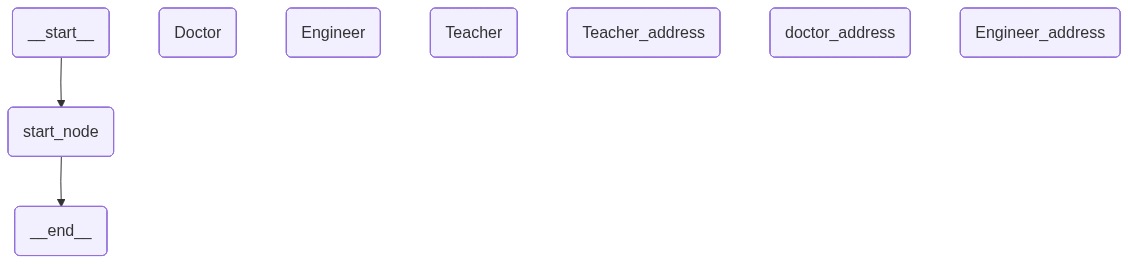

In [3]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
builder = StateGraph(TypedDict_State)
# Add nodes

builder.add_node('start_node' , start_node) # node 1

#Occupation nodes
builder.add_node('Doctor' , Doctor)         # node 2
builder.add_node('Engineer' , Engineer)     # node 3
builder.add_node('Teacher' , Teacher)    # node 4

# Address nodes
builder.add_node('Teacher_address' , Teacher_address)    # node 5
builder.add_node('doctor_address' , doctor_address)    # node 6
builder.add_node('Engineer_address' , Engineer_address)    # node 7

# add edges
builder.set_entry_point('start_node')    
builder.add_conditional_edges('start_node' , decide_occupation)
occu_nodes = ['Doctor' , 'Engineer' , 'Teacher']
for node in occu_nodes:
    builder.add_conditional_edges(node , decide_address)

addr_nodes = ['Teacher_address' , 'doctor_address', 'Engineer_address']
for node in addr_nodes:
    builder.add_edge(node , END)

graph = builder.compile()


# View
builder.compile()      
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
result = graph.invoke({'name': 'Diya' , 'age': 23})

Node 1: first node
Node 8: decide_occupation node
Node 3: Engineer node
Node 9: decide_address node
Node 7: Engineer_address node


In [5]:
result
    

{'name': 'Diya',
 'age': 23,
 'address': '345 Engineer city,TX',
 'occupation': 'Engineer'}

In [6]:
graph.invoke({"name": "Chaitha", "age": 25})


Node 1: first node
Node 8: decide_occupation node
Node 2: Doctor node
Node 9: decide_address node
Node 6: doctor_address node


{'name': 'Chaitha',
 'age': 25,
 'address': '123 doctor city,TX',
 'occupation': 'doctor'}

In [7]:
graph.invoke({"name": "SomeoneElse", "age": 30})


Node 1: first node
Node 8: decide_occupation node
Node 4: Teacher node
Node 9: decide_address node
Node 5: Teacher_address node


{'name': 'SomeoneElse',
 'age': 30,
 'address': '234 Teacher city,TX',
 'occupation': 'Teacher'}

# Data Class
#### Dataclasses offer a concise syntax for creating classes that are primarily used to store data.



In [8]:
from dataclasses import dataclass
from typing import Literal

@dataclass
class dataClass_state:
    Excercise_name : str
    rep : int
    set_no :int
    duration : float



    

In [21]:
# create node functions

#node 1
def warm_up(state):
    print("warm up node1")
    
    warmup =  {'Excercise_name':'jumping_jack' , 
               'rep' : 20,
               'set_no': 3 , 
               'duration' :5 }
    print(f"warmup : {warmup}")
    return {'Excercise_name' : state.Excercise_name , 'rep':20 , 'set_no' : 3, 'duration' :5 }

# node 2
def Cardio(state):
    print('Cardio Node 2')
    return { 'rep' :30 , 'set_no' : 4 , 'duration' : 30 }


# node 3
def Strength_Training(state):
    print("Strength_Training node 3")
    return { 'rep' :20 , 'set_no' : 3 , 'duration' : 25.30 }


# decision function
def decide(state)->Literal['cardio' , 'strength_training']:
    if state.Excercise_name.lower()  == 'cardio':
        return 'cardio'     
    elif state.Excercise_name.lower()  == 'strength training':
        return  'strength_training'
    


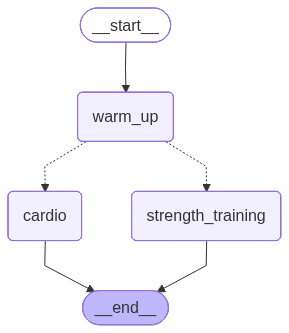

In [22]:
# crfeate nodes and edges

# from langgraph.graph import StateGraph , START , END

builder = StateGraph(dataClass_state)

builder.add_node('warm_up' , warm_up)
builder.add_node('cardio' , Cardio)
builder.add_node('strength_training' , Strength_Training)

# edges
#builder.set_entry_point('warm_up')
builder.add_edge(START, "warm_up")
builder.add_conditional_edges('warm_up' , decide)
builder.add_edge('cardio' , END)
builder.add_edge('strength_training' , END)

# graph
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
result = graph.invoke(dataClass_state(Excercise_name = 'Cardio', rep = 0 , set_no = 0 , duration= 0))
result

warm up node1
warmup : {'Excercise_name': 'jumping_jack', 'rep': 20, 'set_no': 3, 'duration': 5}
Cardio Node 2


{'Excercise_name': 'Cardio', 'rep': 30, 'set_no': 4, 'duration': 30}

In [24]:
result = graph.invoke(dataClass_state(Excercise_name = 'Strength training', rep = 0 , set_no = 0 , duration= 0))
result

warm up node1
warmup : {'Excercise_name': 'jumping_jack', 'rep': 20, 'set_no': 3, 'duration': 5}
Strength_Training node 3


{'Excercise_name': 'Strength training',
 'rep': 20,
 'set_no': 3,
 'duration': 25.3}